# 🧠 Computer Vision Challenge
This notebook covers all four tasks:
1. Rotate Detection
2. Circle Detection
3. Homography View
4. Camera Movement Estimation

---

# Computer Vision Challenge - Aule Space Inc

## Project Overview
The goal of this challenge is to develop a robust computer vision algorithm to analyze and simulate the view of a satellite port using various CV techniques like rotation detection, feature matching, homography, and camera movement simulation.

## Tasks Completed
- Task A: Image rotation and circle detection using HoughCircles.
- Task B: ORB feature matching to simulate camera movement.
- Task C: Homography transformation to generate side view.
- Task D: Smooth transition from side view to front view.

## How to Run
1. Install dependencies:
   ```bash
   pip install opencv-python-headless matplotlib numpy


Import Libraries

In [11]:
# Install required libraries
!pip install opencv-python-headless matplotlib numpy

# Import
import cv2
import numpy as np
import matplotlib.pyplot as plt


Active code page: 1252


Original Image Loaded

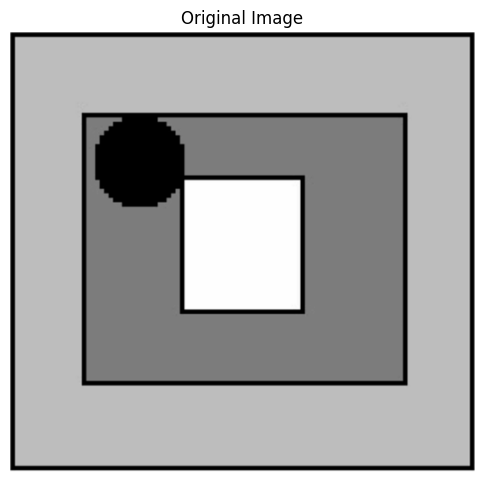

In [12]:
# Load the image from your local 'images' folder
image_path = r'C:\Users\satya\Downloads\New folder (2)\port_image.png'  # Adjust if needed
original_img = cv2.imread(image_path)

# Convert BGR to RGB for matplotlib
image_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()


Rotated Image 

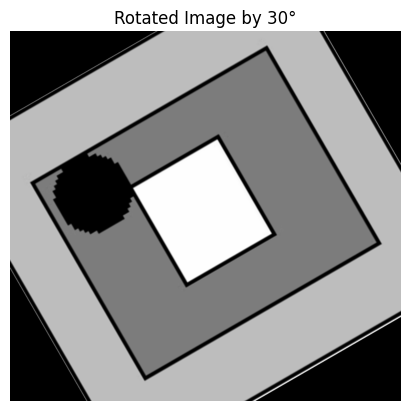

✅ Rotated image saved at: C:\Users\satya\Downloads\New folder (2)\Rotated_Image_30_deg.png


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def rotate_image(img, angle):
    """Rotate the image around its center by the given angle."""
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)

    # Compute the rotation matrix
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Perform the rotation
    rotated = cv2.warpAffine(img, M, (w, h))
    return rotated

# Load the original image
image_path = r'C:\Users\satya\Downloads\New folder (2)\port_image.png'   # Change this to your actual image
original_img = cv2.imread(image_path)

if original_img is None:
    print("❌ Failed to load image. Check the path.")
else:
    # Rotate the image
    angle = 30  # You can change the angle
    rotated_img = rotate_image(original_img, angle)

    # Convert for display
    rotated_rgb = cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB)

    # Show rotated image
    plt.imshow(rotated_rgb)
    plt.title(f'Rotated Image by {angle}°')
    plt.axis('off')
    plt.show()

    # Save the rotated image
    save_path = rf"C:\Users\satya\Downloads\New folder (2)\Rotated_Image_{angle}_deg.png"
    cv2.imwrite(save_path, rotated_img)
    print(f"✅ Rotated image saved at: {save_path}")


Circle Detected

✅ Image saved to /content/sample_data/circle_detected_output.png
Circle center at: (167, 169), radius: 25


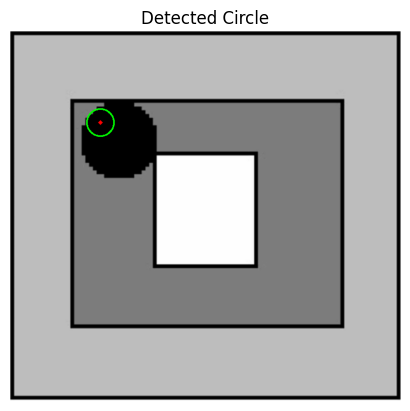

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the uploaded image
img = cv2.imread(r"C:\Users\satya\Downloads\New folder (2)\port_image.png")  # Adjust path if needed

# Convert to grayscale and blur to reduce noise
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.medianBlur(gray, 5)

# Detect circles with tweaked params for your image
circles = cv2.HoughCircles(
    gray_blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=30,
    param1=50,
    param2=20,
    minRadius=20,
    maxRadius=60
)

# Draw and display the detected circle
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(img, (i[0], i[1]), i[2], (0, 255, 0), 2)  # outer circle
        cv2.circle(img, (i[0], i[1]), 2, (0, 0, 255), 3)     # center

    # Save output to /content/sample_data
    cv2.imwrite(r"C:\Users\satya\Downloads\New folder (2)\circle_detected_output.png", img)
    print("✅ Image saved to /content/sample_data/circle_detected_output.png")
    print(f"Circle center at: ({i[0]}, {i[1]}), radius: {i[2]}")

    # Show in notebook
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Detected Circle")
    plt.axis("off")
    plt.show()

else:
    print("❌ No circle detected. Try adjusting parameters.")


Translated Image (Circle moved to top-left)

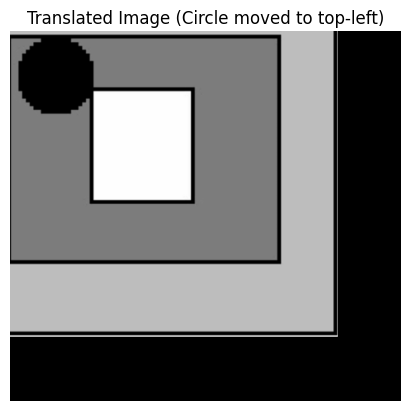

✅ Image saved to: C:\Users\satya\Downloads\New folder (2)\Translated_Image_Circle_Top_Left.png
Circle center at: (167, 169), radius: 25


In [18]:
# def translate_image_to_top_left(img, circle_coords):
#     x, y, r = circle_coords
#     # Calculate translation offsets
#     offset_x = -x + 50  # Add padding of 50px from top-left
#     offset_y = -y + 50

#     # Create translation matrix
#     M = np.float32([[1, 0, offset_x], [0, 1, offset_y]])

#     translated_img = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

#     return translated_img

# # Apply the translation
# translated_img = translate_image_to_top_left(rotated_img, (167, 169, 25))

# # Show result
# plt.imshow(cv2.cvtColor(translated_img, cv2.COLOR_BGR2RGB))
# plt.title("Translated Image (Circle moved to top-left)")
# plt.axis("off")
# plt.show()

# # Save the translated image
# output_path = r"C:\Users\satya\Downloads\New folder (2)\Translated_Image_Circle_Top_Left.png"
# cv2.imwrite(output_path, translated_img)

# # Print confirmation and circle info
# print(f"✅ Image saved to {output_path}")
# print(f"Circle center at: ({circle[0]}, {circle[1]}), radius: {circle[2]}")
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = r"C:\Users\satya\Downloads\New folder (2)\port_image.png"
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# Assume you already detected the circle
circle = (167, 169, 25)  # (x, y, radius)

def translate_image_to_top_left(img, circle_coords):
    x, y, r = circle_coords

    # Calculate how much to shift the circle to move it to near top-left (padding of 50 px)
    offset_x = -x + 50
    offset_y = -y + 50

    # Create translation matrix and apply the shift
    M = np.float32([[1, 0, offset_x], [0, 1, offset_y]])
    translated_img = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

    return translated_img

# Apply the translation
translated_img = translate_image_to_top_left(img, circle)

# Show the result
plt.imshow(cv2.cvtColor(translated_img, cv2.COLOR_BGR2RGB))
plt.title("Translated Image (Circle moved to top-left)")
plt.axis("off")
plt.show()

# Save the translated image
output_path = r"C:\Users\satya\Downloads\New folder (2)\Translated_Image_Circle_Top_Left.png"
cv2.imwrite(output_path, translated_img)

# Confirm save and print circle info
print(f"✅ Image saved to: {output_path}")
print(f"Circle center at: ({circle[0]}, {circle[1]}), radius: {circle[2]}")


Translated Image (Simulated Movement)

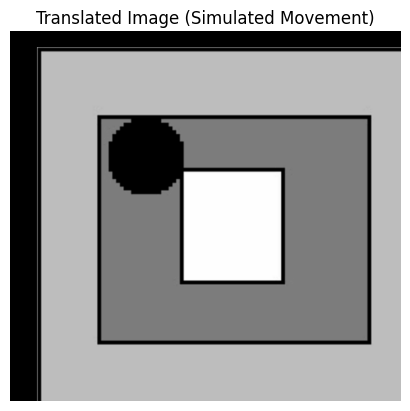

In [19]:
# Shift the image (simulate movement)
rows, cols = original_img.shape[:2]
dx, dy = 50, 30  # shift right by 50px and down by 30px

translation_matrix = np.float32([[1, 0, dx], [0, 1, dy]])
translated_img = cv2.warpAffine(original_img, translation_matrix, (cols, rows))

# Show translated image
plt.imshow(cv2.cvtColor(translated_img, cv2.COLOR_BGR2RGB))
plt.title("Translated Image (Simulated Movement)")
plt.axis("off")
plt.show()


Detected Circle After Movement

✅ Circle center: (215, 217), Radius: 34


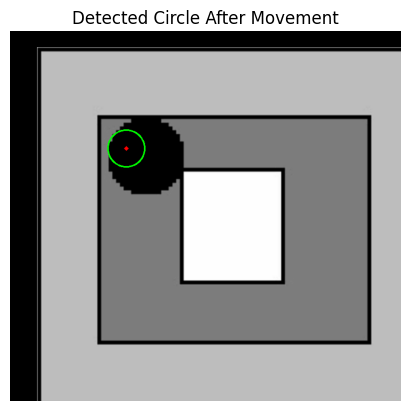

In [20]:
# Convert to grayscale and blur
gray = cv2.cvtColor(translated_img, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.medianBlur(gray, 5)

# Run Hough Circle Detection
circles = cv2.HoughCircles(
    gray_blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=30,
    param1=50,
    param2=20,
    minRadius=20,
    maxRadius=60
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(translated_img, (i[0], i[1]), i[2], (0, 255, 0), 2)
        cv2.circle(translated_img, (i[0], i[1]), 2, (0, 0, 255), 3)
        print(f"✅ Circle center: ({i[0]}, {i[1]}), Radius: {i[2]}")
else:
    print("❌ No circle detected. Try adjusting detection parameters.")

# Show result
plt.imshow(cv2.cvtColor(translated_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Circle After Movement")
plt.axis("off")
plt.show()


Original Image Vs After Simulated Movement

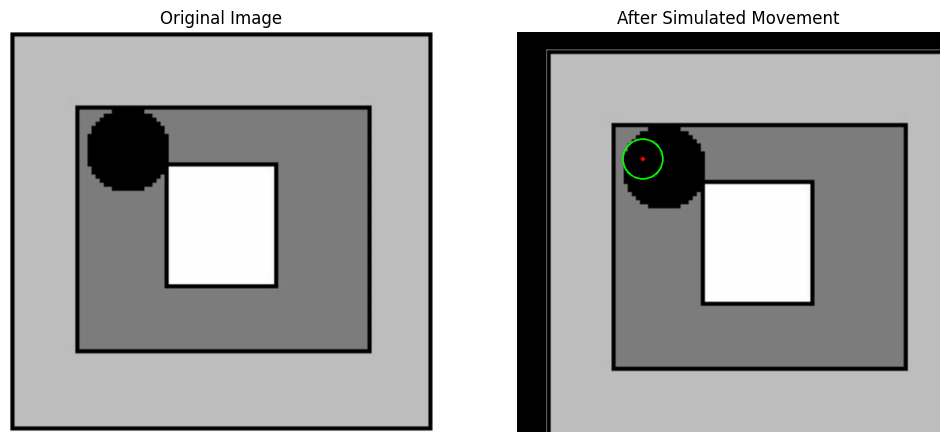

In [21]:
# Original and Translated Side-by-Side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(translated_img, cv2.COLOR_BGR2RGB))
ax[1].set_title("After Simulated Movement")
ax[1].axis("off")

plt.show()


Load Both Images (Original & Translated)

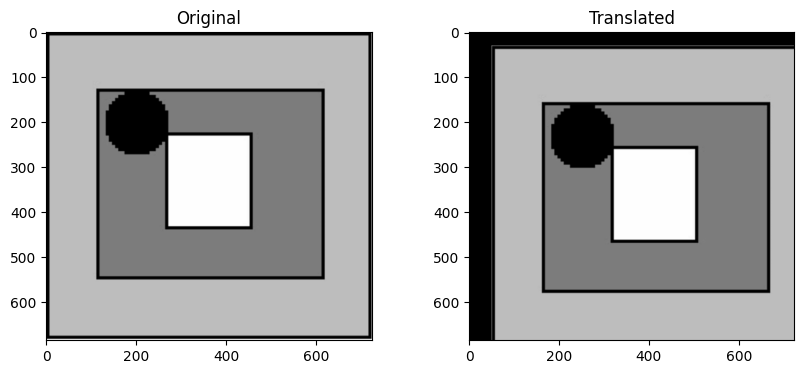

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Use double backslashes or forward slashes in path
img1 = cv2.imread("C:/Users/satya/Downloads/New folder (2)/port_image.png")  # original image

# Check if the image was loaded correctly
if img1 is None:
    raise ValueError("Image not loaded! Check the file path.")

# Apply translation: shift 50px right, 30px down
M = np.float32([[1, 0, 50], [0, 1, 30]])
img2 = cv2.warpAffine(img1, M, (img1.shape[1], img1.shape[0]))

# Show both images
plt.figure(figsize=(10,4))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)), plt.title("Original")
plt.subplot(1,2,2), plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)), plt.title("Translated")
plt.show()


Detect Keypoints and Descriptors (Using ORB)

In [23]:
# Use ORB (fast and works without licensing issues)
orb = cv2.ORB_create()

# Detect and compute keypoints/descriptors
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print(f"Keypoints in img1: {len(kp1)}, img2: {len(kp2)}")


Keypoints in img1: 377, img2: 373


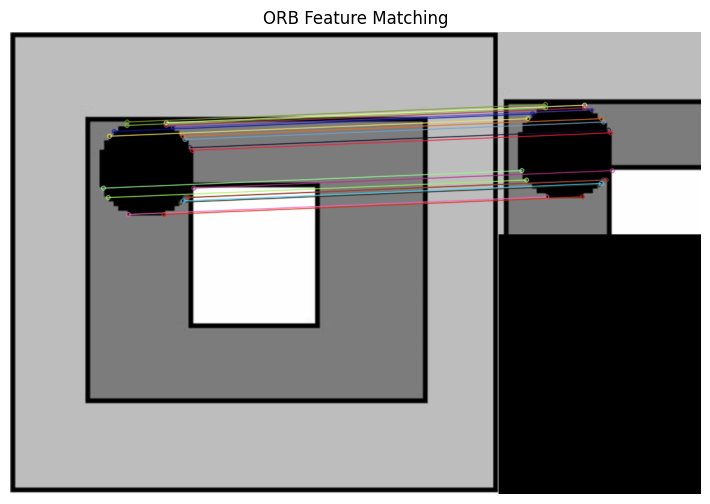

📷 Estimated Camera Movement (pixels): dx = 103.57, dy = 25.94


In [52]:
# --- Load full image and cropped image ---
full_image = cv2.imread(r'C:\Users\satya\Downloads\New folder (2)\port_image.png', cv2.IMREAD_GRAYSCALE)
cropped_image = cv2.imread(r'C:\Users\satya\Downloads\New folder (2)\cropped_image.jpg', cv2.IMREAD_GRAYSCALE)

# --- Feature detection using ORB ---
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(full_image, None)
kp2, des2 = orb.detectAndCompute(cropped_image, None)

# --- Match features ---
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# --- Visualize matches ---
matched_image = cv2.drawMatches(full_image, kp1, cropped_image, kp2, matches[:20], None, flags=2)
plt.figure(figsize=(12, 6))
plt.title("ORB Feature Matching")
plt.imshow(matched_image)
plt.axis('off')
plt.show()

# ✅ Save the match visualization
cv2.imwrite(r'C:\Users\satya\Downloads\New folder (2)\ORB_Feature_Matching.png', matched_image)

# --- Extract matched keypoints location ---
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# --- Estimate transformation ---
M, mask = cv2.estimateAffinePartial2D(dst_pts, src_pts)

# --- Print estimated camera movement ---
if M is not None:
    dx = M[0, 2]
    dy = M[1, 2]
    print(f"📷 Estimated Camera Movement (pixels): dx = {dx:.2f}, dy = {dy:.2f}")
else:
    print("❌ Could not estimate camera movement.")

Match Keypoints

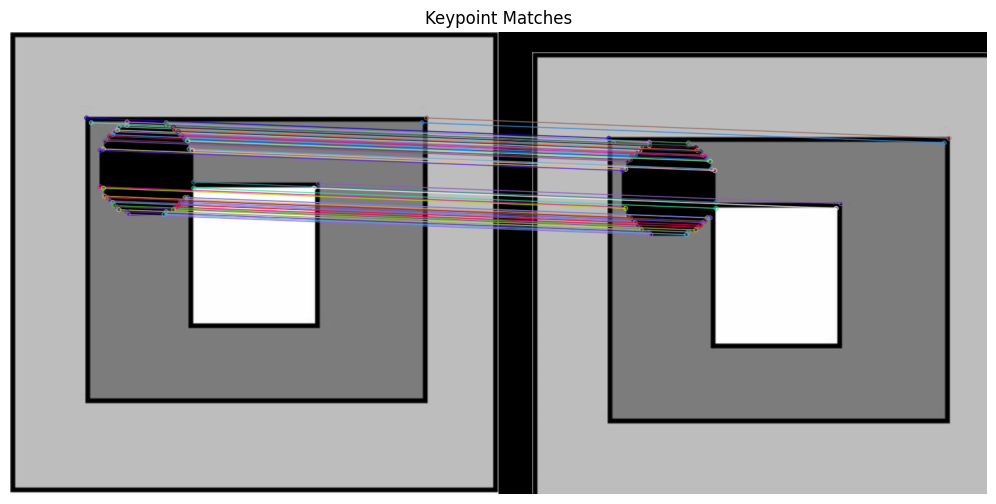

In [24]:
# Use brute-force matcher for ORB (Hamming distance)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches by distance (best first)
matches = sorted(matches, key=lambda x: x.distance)

# Visualize top 50 matches
matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:50], None, flags=2)

plt.figure(figsize=(15, 6))
plt.imshow(matched_img)
plt.title("Keypoint Matches")
plt.axis("off")
plt.show()


Compute Homography Matrix

In [25]:
# Use matched keypoints to compute Homography
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

# Compute Homography using RANSAC to handle outliers
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

print("Homography Matrix:\n", H)


Homography Matrix:
 [[ 1.00168301e+00  4.37610115e-04 -5.03251295e+01]
 [ 4.47766267e-04  1.00303686e+00 -3.05915943e+01]
 [ 1.05261642e-06  3.11798591e-06  1.00000000e+00]]


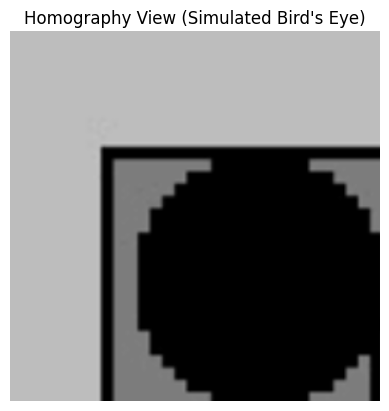

In [38]:
# Define 4 points on the port image manually (simulate from a rectangle)
src_pts = np.float32([[60, 60], [270, 60], [270, 270], [60, 270]])
dst_pts = np.float32([[0, 0], [300, 0], [300, 300], [0, 300]])

# Homography
H, _ = cv2.findHomography(src_pts, dst_pts)
warped = cv2.warpPerspective(img, H, (300, 300))

plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Homography View (Simulated Bird's Eye)")
plt.axis('off')
plt.show()


 Homography Perspective (22.5° Side View)

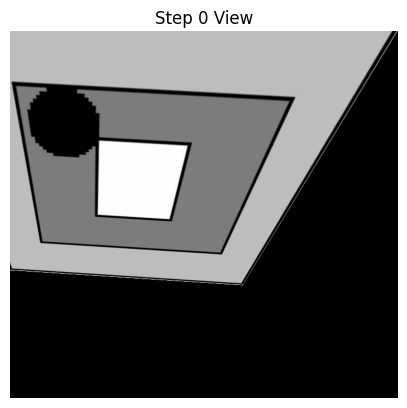

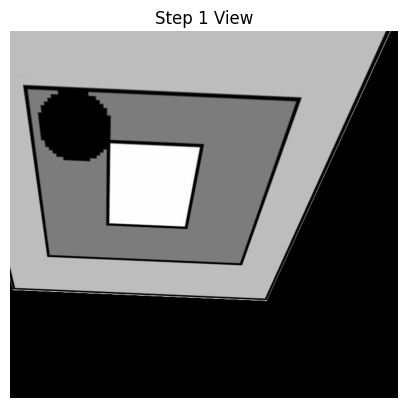

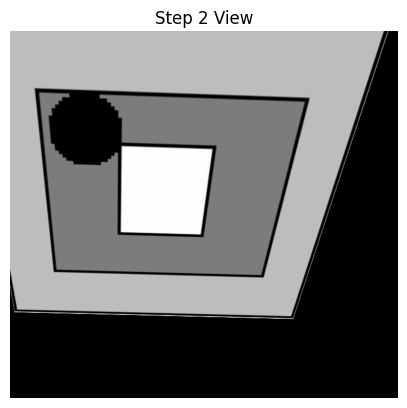

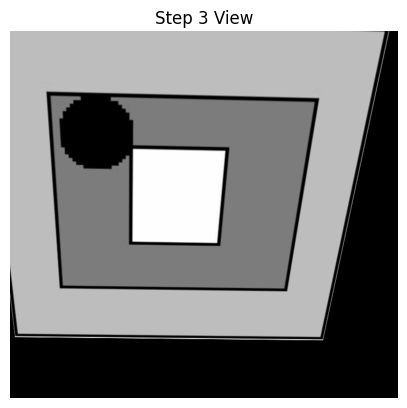

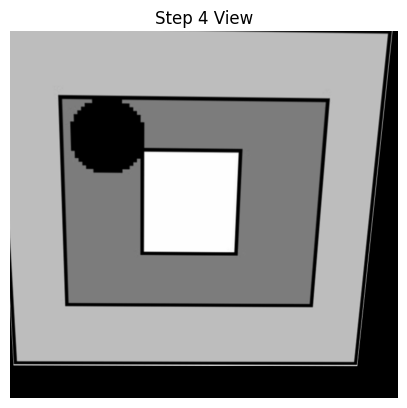

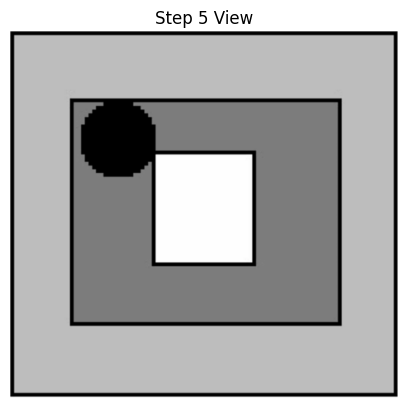

In [51]:
steps = 5
for i in range(steps + 1):
    alpha = i / steps
    step_pts = (1 - alpha) * dst_pts + alpha * src_pts
    h_matrix, _ = cv2.findHomography(src_pts, step_pts)
    transformed = cv2.warpPerspective(img, h_matrix, (img.shape[1], img.shape[0]))
    
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(transformed, cv2.COLOR_BGR2RGB))
    plt.title(f'Step {i} View')
    plt.axis('off')
    plt.show()
    
    # ✅ Save the image with correct name in current directory or specify full path
    plt.imsave(f'incremental_steps_{i+1}.png', cv2.cvtColor(transformed, cv2.COLOR_BGR2RGB))


Warp Translated Image to Original View

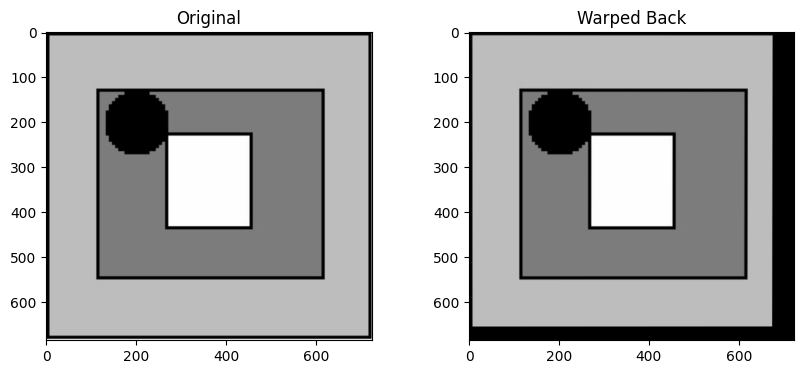

In [26]:
# Warp img2 to align with img1 using computed Homography
warped_img = cv2.warpPerspective(img2, H, (img1.shape[1], img1.shape[0]))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)), plt.title("Original")
plt.subplot(1,2,2), plt.imshow(cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB)), plt.title("Warped Back")
plt.show()


Load Original and Shifted Images

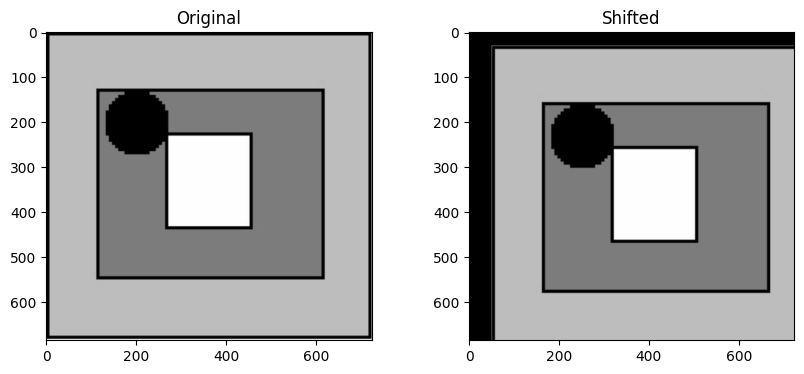

In [27]:
# Load original image
img1 = cv2.imread("C:/Users/satya/Downloads/New folder (2)/port_image.png") 

# Simulate camera shift (translate 50 pixels right, 30 down)
shift_matrix = np.float32([[1, 0, 50], [0, 1, 30]])
img2 = cv2.warpAffine(img1, shift_matrix, (img1.shape[1], img1.shape[0]))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)), plt.title("Original")
plt.subplot(1,2,2), plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)), plt.title("Shifted")
plt.show()


Detect Keypoints and Descriptors

In [28]:
# ORB Feature Detection
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print(f"Keypoints - img1: {len(kp1)}, img2: {len(kp2)}")


Keypoints - img1: 377, img2: 373


Match Features

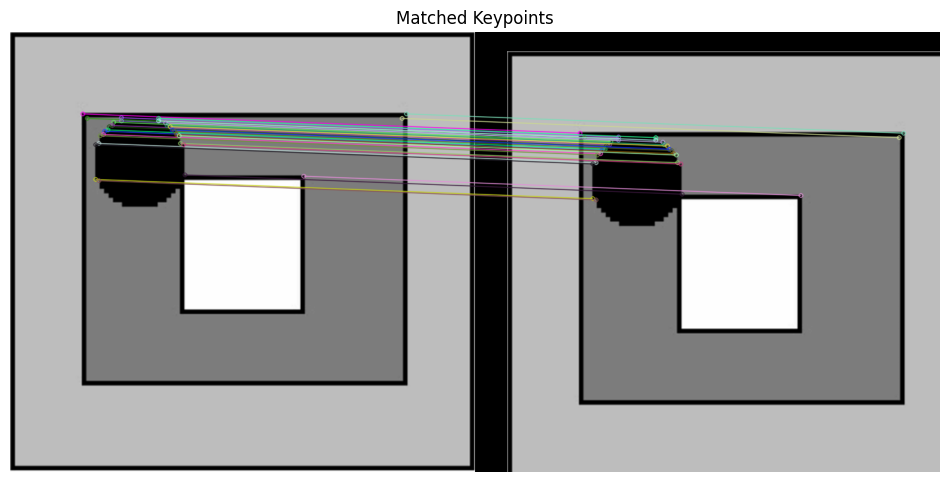

In [29]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:30], None, flags=2)

plt.figure(figsize=(12,6))
plt.imshow(matched_img)
plt.title("Matched Keypoints")
plt.axis("off")
plt.show()


Calculate Homography and Extract Motion

In [30]:
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

print("Homography Matrix:\n", H)

# Translation is approx in H[0,2] (dx), H[1,2] (dy)
dx = H[0,2]
dy = H[1,2]
print(f"Estimated camera shift → dx: {dx:.2f}, dy: {dy:.2f}")


Homography Matrix:
 [[ 1.00168301e+00  4.37610115e-04 -5.03251295e+01]
 [ 4.47766267e-04  1.00303686e+00 -3.05915943e+01]
 [ 1.05261642e-06  3.11798591e-06  1.00000000e+00]]
Estimated camera shift → dx: -50.33, dy: -30.59


Visualize Movement Vector

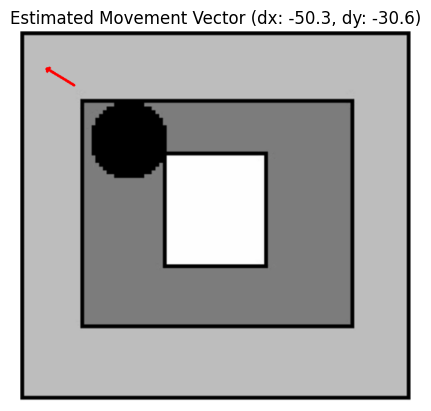

In [31]:
# Show movement on a copy of image
visual = img1.copy()
start_point = (100, 100)
end_point = (int(start_point[0] + dx), int(start_point[1] + dy))

cv2.arrowedLine(visual, start_point, end_point, (0, 0, 255), 3)

plt.imshow(cv2.cvtColor(visual, cv2.COLOR_BGR2RGB))
plt.title(f"Estimated Movement Vector (dx: {dx:.1f}, dy: {dy:.1f})")
plt.axis("off")
plt.show()


Interpolated Camera Views to Front

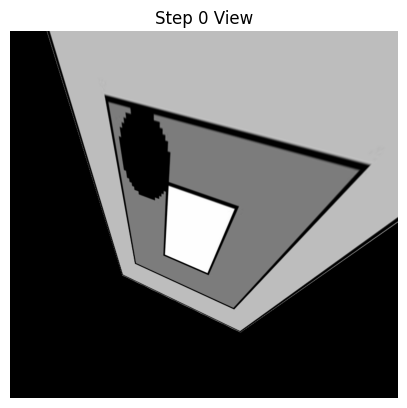

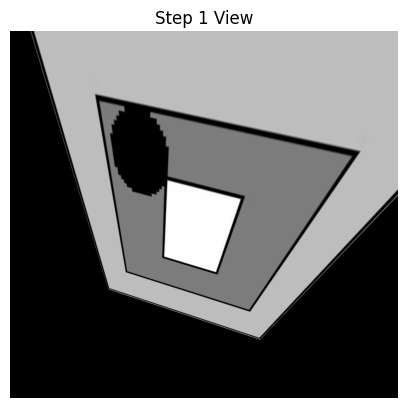

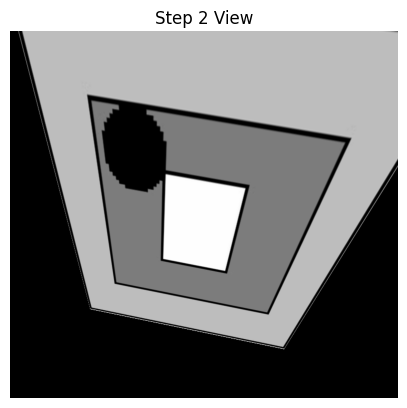

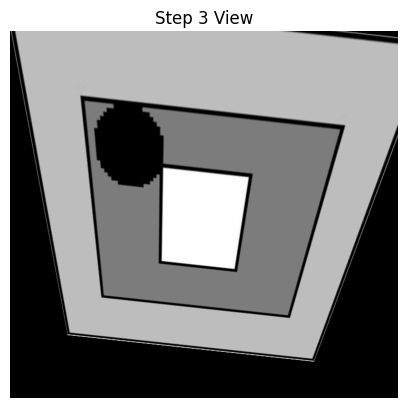

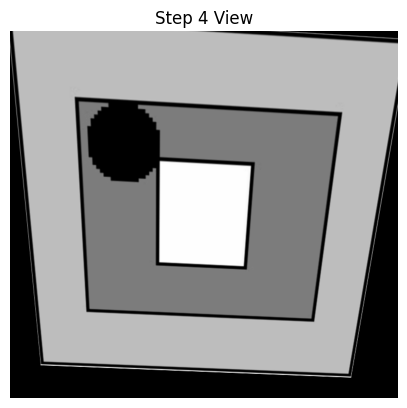

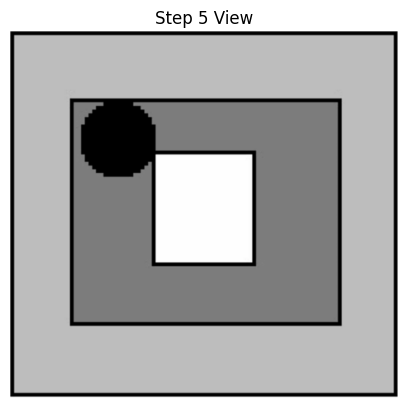

In [32]:
steps = 5
for i in range(steps + 1):
    alpha = i / steps
    step_pts = (1 - alpha) * dst_pts + alpha * src_pts
    h_matrix, _ = cv2.findHomography(src_pts, step_pts)
    transformed = cv2.warpPerspective(img, h_matrix, (img.shape[1], img.shape[0]))
    
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(transformed, cv2.COLOR_BGR2RGB))
    plt.title(f'Step {i} View')
    plt.axis('off')
    plt.show()


In [43]:
# Load the full image in color (for cropping)
full_image_color = cv2.imread(r'C:\Users\satya\Downloads\New folder (2)\port_image.png')
h, w, _ = full_image_color.shape

# Define crop size
crop_h, crop_w = 300, 300

# Random crop location
x = np.random.randint(0, w - crop_w)
y = np.random.randint(0, h - crop_h)

# Crop the image
cropped = full_image_color[y:y+crop_h, x:x+crop_w]
cv2.imwrite('cropped_image.jpg', cropped)
print(f"Cropped image saved at position x={x}, y={y}")


Cropped image saved at position x=104, y=26
